In [1]:
import os
import sys
import json
import random
from PIL import Image
from pathlib import Path
from typing import Any, Dict, Iterator, List, Optional

import torch
from torch.utils.data import IterableDataset
from datasets import load_dataset, interleave_datasets
from transformers import Trainer, TrainingArguments, set_seed
from matplotlib import pyplot as plt

import sys
sys.path.insert(0, "../")

from src.model.gigachat_vl import GigaChatVLForInference
from src.model.smollm3_vl import SmolLM3VLForInference

Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu130 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [2]:
# checkpoint_dir = "/media/alexey/SSDData/experiments/gigachat_vl/outputs/gigachat_vl_siglipv2_projector/checkpoint-5000/"
checkpoint_dir = "/media/alexey/SSDData/experiments/gigachat_vl/outputs/gigachat_vl/"  # after final save_artifacts(...)
LLM_PATH = "/media/alexey/HDDLargeData/models/LLM/GigaChat3.1-10B-A1.8B-bf16"
# checkpoint_dir = "/media/alexey/SSDData/experiments/smollm3_vl/outputs/smollm3_vl/"

model = GigaChatVLForInference(
    checkpoint_dir=checkpoint_dir,
    llm_name=LLM_PATH,
    use_4bit_llm=True,
)
# model = SmolLM3VLForInference(
#     checkpoint_dir=checkpoint_dir,
#     use_4bit_llm=True
# )

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Some weights of the model checkpoint at /media/alexey/HDDLargeData/models/LLM/GigaChat3.1-10B-A1.8B-bf16 were not used when initializing DeepseekV3ForCausalLM: ['model.layers.26.eh_proj.weight', 'model.layers.26.embed_tokens.weight', 'model.layers.26.enorm.weight', 'model.layers.26.hnorm.weight', 'model.layers.26.input_layernorm.weight', 'model.layers.26.mlp.experts.0.down_proj.weight', 'model.layers.26.mlp.experts.0.gate_proj.weight', 'model.layers.26.mlp.experts.0.up_proj.weight', 'model.layers.26.mlp.experts.1.down_proj.weight', 'model.layers.26.mlp.experts.1.gate_proj.weight', 'model.layers.26.mlp.experts.1.up_proj.weight', 'model.layers.26.mlp.experts.10.down_proj.weight', 'model.layers.26.mlp.experts.10.gate_proj.weight', 'model.layers.26.mlp.experts.10.up_proj.weight', 'model.layers.26.mlp.experts.11.down_proj.weight', 'model.layers.26.mlp.experts.11.gate_proj.weight', 'model.layers.26.mlp.experts.11.up_proj.weight', 'model.layers.26.mlp.experts.12.down_proj.weight', 'model.laye

Note: base LLM checkpoint contains an extra MTP block (210 tensors under `model.layers.26.*`). Transformers `DeepseekV3ForCausalLM` does not load this auxiliary MTP block for standard causal LM training/inference, so these unexpected keys are expected and can be ignored.


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


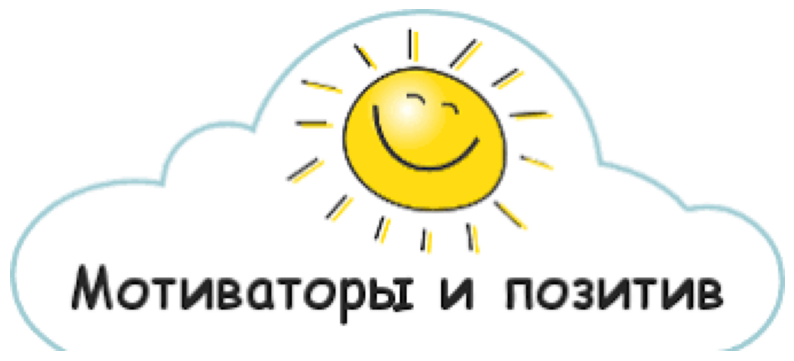

Я не могу просматривать изображения или файлы, включая фотографии и скриншоты. Однако ты можешь просто скопировать и вставить сюда текст, который хочешь извлечь. Если нужно, я помогу обработать или проанализировать этот текст.


In [4]:
image_path = "/home/alexey/Downloads/ocr_test_2.png"
image = Image.open(image_path)
# image = None

if image is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

prompt = "Извлеки весь текст из изображения."
# prompt = "Что на изображении?"

out = model.inference(
    text=prompt,
    image=image,
    do_sample=False,
    max_new_tokens=256,
    temperature=0.7,
    repetition_penalty=1.05
)

print(out)

In [4]:
dbg = model.debug_multimodal_inputs(text=prompt, image=image)
print(dbg)

eff = model.debug_visual_embedding_effect(text=prompt, image=image)
print(eff)

{'vision_backend': 'gemma4', 'vision_name': '/media/alexey/HDDLargeData/models/VLM/gemma-4-31B-it/', 'projector_type': 'mlp', 'connector_llm_name': None, 'connector_llm_use_qlora': False, 'connector_is_peft': False, 'connector_is_quantized': False, 'num_images': 1, 'image_token': '[image_token]', 'image_token_id': 128256, 'prompt_image_token_count': 1, 'input_image_token_count': 275, 'visual_token_count': 275, 'prompt_token_length': 80, 'merged_sequence_length': 354, 'has_inputs_embeds': True, 'inputs_embeds_shape': (1, 354, 2048), 'attention_mask_shape': (1, 354), 'visual_embed_norm_mean': 45.25, 'text_embed_norm_mean': 5.875}
{'has_inputs_embeds': True, 'visual_token_count': 275, 'max_abs_logit_diff': 4.09375, 'mean_abs_logit_diff': 0.7975545525550842}
